# Goal: Build a simple credit risk model

In [60]:
import numpy as np
import pandas as pd

# Data Collection

In [ ]:
# Make data and save it to CSV

from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    random_state=42
)

columns = [
    'income', 'loan_amount', 'credit_history',
    'age', 'balance'
]

df = pd.DataFrame(X, columns=columns)

# Convert to realistic ranges (unnormalized data)
df['income'] = ((df['income'] * 20000) + 50000).round(2)        # ₹30k – ₹1L+
df['loan_amount'] = ((df['loan_amount'] * 50000) + 200000).round(2)  # ₹1L – ₹5L
df['credit_history'] = ((df['credit_history'] * 2) + 5).round(0).astype(int) # 0–10 scale
df['age'] = ((df['age'] * 10) + 35).round(0).astype(int) # 20–60
df['balance'] = ((df['balance'] * 30000) + 100000).round(2)   # bank balance

df['default'] = y

# print("Raw Data (Unnormalized):")
# df.to_csv("data_credit_raw.csv", index=False)

Raw Data (Unnormalized):


In [ ]:
# 1) Load the data

df_loaded = pd.read_csv("data_credit_raw.csv")

print(df_loaded.head())


     income  loan_amount  credit_history  age    balance  default
0  48694.00    164139.29               6   26  150445.42        0
1  61340.29    197769.68               8   21  174666.33        0
2  45055.69    167471.53               4   23  125233.29        0
3  72917.41    248711.22               8   12  168295.62        1
4  61992.09    178622.74              10   20  208148.77        0


In [63]:
# 2) scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Only normalize feature columns
X_scaled = scaler.fit_transform(df[columns])

df_scaled = pd.DataFrame(X_scaled, columns=columns)
df_scaled['default'] = y

print("\n🔹 Normalized Data:")
print(df_scaled.head())


🔹 Normalized Data:
     income  loan_amount  credit_history       age   balance  default
0 -0.389131    -0.606581        0.016663 -0.318061  0.521880        0
1  0.554459    -0.045151        0.791697 -0.718642  0.999663        0
2 -0.660600    -0.550952       -0.758370 -0.558410  0.024545        0
3  1.418274     0.805273        0.791697 -1.439688  0.873994        1
4  0.603092    -0.364793        1.566731 -0.798758  1.660138        0


In [64]:
df = df_scaled

# Step 2: Split data + Train Model

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [65]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

# (OPTIONAL):  Do this at the end: 
- We can use hyperparameter tuning to find the best model

In [80]:

# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# import numpy as np

# # Define models and parameter grids
# models = {
#     "logistic": (
#         LogisticRegression(max_iter=1000),
#         {
#             "C": np.logspace(-3, 3, 10),
#             "penalty": ["l2"]
#         }
#     ),
    
#     "random_forest": (
#         RandomForestClassifier(),
#         {
#             "n_estimators": [50, 100, 200],
#             "max_depth": [None, 5, 10],
#             "min_samples_split": [2, 5, 10]
#         }
#     ),
    
#     "svm": (
#         SVC(probability=True),
#         {
#             "C": np.logspace(-3, 3, 10),
#             "kernel": ["linear", "rbf"]
#         }
#     )
# }

# best_model = None
# best_score = 0
# best_name = ""
# best_params = None

# # Loop through models
# for name, (model, params) in models.items():
    
#     print(f"\n🔍 Tuning {name}...")
    
#     random_search = RandomizedSearchCV(
#         model,
#         param_distributions=params,
#         n_iter=5,   # keep small for class demo
#         cv=3,
#         scoring='accuracy',
#         random_state=42,
#         n_jobs=-1
#     )
    
#     random_search.fit(X_train, y_train)
    
#     print("Best Score:", random_search.best_score_)
#     print("Best Params:", random_search.best_params_)
    
#     # Track best model overall
#     if random_search.best_score_ > best_score:
#         best_score = random_search.best_score_
#         best_model = random_search.best_estimator_
#         best_name = name
#         best_params = random_search.best_params_

# # Final best model
# print("\n🏆 Best Model Selected:")
# print("Model:", best_name)
# print("Score:", best_score)
# print("Best Parameters:", best_params)

# model = best_model


🔍 Tuning logistic...
Best Score: 0.9075169196399239
Best Params: {'penalty': 'l2', 'C': 0.001}

🔍 Tuning random_forest...
Best Score: 0.937512320126158
Best Params: {'n_estimators': 50, 'min_samples_split': 2, 'max_depth': None}

🔍 Tuning svm...
Best Score: 0.9487529685637314
Best Params: {'kernel': 'rbf', 'C': 46.41588833612773}

🏆 Best Model Selected:
Model: svm
Score: 0.9487529685637314
Best Parameters: {'kernel': 'rbf', 'C': 46.41588833612773}


# Step3: Prediction

In [82]:
# 1) 
new_customers = pd.DataFrame([
    [0.5, 1.2, -0.3, 0.8, -1.0],   # Customer 1
    [-1.5, 0.3, 1.1, -0.2, 0.5]    # Customer 2
], columns=X.columns)

predictions = model.predict(new_customers)
probabilities = model.predict_proba(new_customers)[:, 1]

print("predictions:", predictions)
print("probabilities:", probabilities)

predictions: [1 0]
probabilities: [0.94022527 0.44529286]


In [83]:
# 2) Show results
for i in range(len(new_customers)):
    print(f"\nCustomer {i+1}:")
    print("Predicted Class (0=Safe, 1=Default Risk):", predictions[i])
    print("Probability of Default:", round(probabilities[i], 3))


Customer 1:
Predicted Class (0=Safe, 1=Default Risk): 1
Probability of Default: 0.94

Customer 2:
Predicted Class (0=Safe, 1=Default Risk): 0
Probability of Default: 0.445


In [84]:
y_pred = model.predict(X_test)

print("Predicted:", list(y_pred[:18])) # Compare first 18 
print("Actual   :", list(y_test[:18]))

Predicted: [0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1]
Actual   : [0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1]


In [85]:
# Lets look at the probabilities

y_prob = model.predict_proba(X_test)[:,1]
print("Probability of Default:\n", np.round(y_prob[:18],3)) # first 18 

Probability of Default:
 [0.036 0.867 0.051 0.921 0.945 0.007 0.07  0.641 0.993 0.95  0.914 0.96
 0.92  0.025 0.004 0.976 0.968 0.984]


In [86]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)


array([[ 88,   6],
       [  1, 105]], dtype=int64)

In [87]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.94      0.96        94
           1       0.95      0.99      0.97       106

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200



In [88]:
# Threshold for approval: 
# threshold = 0.3 # 0.3, 0.5
from collections import Counter

# Threshold 0.3: Lower threshold → more customers flagged risky
y_custom1 = (y_prob > 0.3).astype(int)
print("First 18 predictions (threshold=0.3):")
print(y_custom1[:18])

print("\nCount (threshold=0.3):")
print(Counter(y_custom1))


# Threshold 0.5: Higher threshold → more customers approved
y_custom2 = (y_prob > 0.5).astype(int)
print("\nFirst 18 predictions (threshold=0.5):")
print(y_custom2[:18])

print("\nCount (threshold=0.5):")
print(Counter(y_custom2))

# 0 → Safe customers
# 1 → Risky customers

First 18 predictions (threshold=0.3):
[0 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1]

Count (threshold=0.3):
Counter({1: 116, 0: 84})

First 18 predictions (threshold=0.5):
[0 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1]

Count (threshold=0.5):
Counter({1: 111, 0: 89})


# Lets visualize above

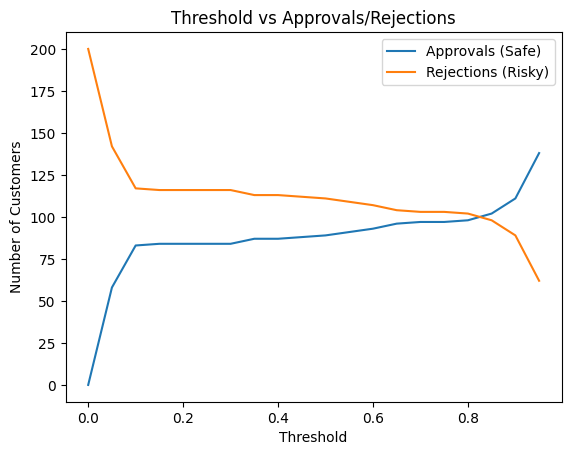

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

thresholds = np.arange(0.0, 1.0, 0.05)

approvals = []   # count of safe customers (0)
rejections = []  # count of risky customers (1)

for t in thresholds:
    y_temp = (y_prob > t).astype(int)
    count = Counter(y_temp)
    
    approvals.append(count[0])   # safe
    rejections.append(count[1])  # risky

# Plot
plt.figure()
plt.plot(thresholds, approvals, label="Approvals (Safe)")
plt.plot(thresholds, rejections, label="Rejections (Risky)")
plt.xlabel("Threshold")
plt.ylabel("Number of Customers")
plt.title("Threshold vs Approvals/Rejections")
plt.legend()
plt.show()


# observation: 
```
Left side (low threshold):
→ More rejections (bank is strict)
Right side (high threshold):
→ More approvals (bank is risky)
```

👉 Ask:

“Where should bank operate?”

# ROC Curve (VERY IMPORTANT)

```
👉 Shows trade-off between:

True Positive Rate (Recall)
False Positive Rate

[           inf 1.00000000e+00 9.77051104e-01 9.76914248e-01
 9.39411234e-01 9.38398207e-01 8.46155336e-01 8.39342716e-01
 6.41306199e-01 6.24768914e-01 5.94009177e-01 5.71981428e-01
 5.44776012e-01 4.23349838e-01 3.28323180e-01 6.03298658e-04]


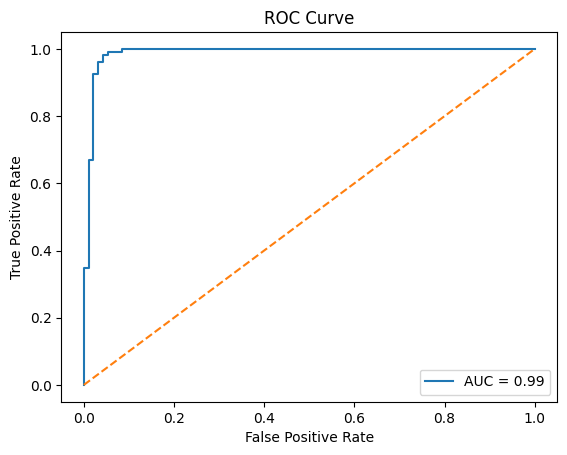

In [90]:
from sklearn.metrics import roc_curve, auc

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
print(thresholds)

roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



👉 Axis meaning:

X-axis → False alarms (bad for bank)

Y-axis → Correct detections (good for bank)


## AUC Interpretation
```
0.5 → Useless model 😅
0.7 → Good 👍
0.8+ → Strong 💪
0.9+ → Excellent 🚀

# Find best threshold

**"We choose the threshold where the model separates good and bad customers the best."**

```
Intuition
If TPR is high → catching risky customers ✅
If FPR is low → not rejecting good customers ✅

👉 Youden Index finds the sweet spot


In [91]:
# 1) 
import numpy as np
from sklearn.metrics import roc_curve

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Youden's Index
youden_index = tpr - fpr

# Best threshold index
best_idx = np.argmax(youden_index)

best_threshold = thresholds[best_idx]
best_tpr = tpr[best_idx]
best_fpr = fpr[best_idx]

print("Best Threshold:", round(best_threshold, 3))
print("TPR at Best Threshold:", round(best_tpr, 3))
print("FPR at Best Threshold:", round(best_fpr, 3))


Best Threshold: 0.594
TPR at Best Threshold: 0.981
FPR at Best Threshold: 0.043


## Question: “Is this always the best threshold for a bank ?”

```
❌ Not always
✔ Because banks may prefer:

Lower risk → choose lower threshold
More customers → choose higher threshold

# Plot with Best Threshold Highlighted

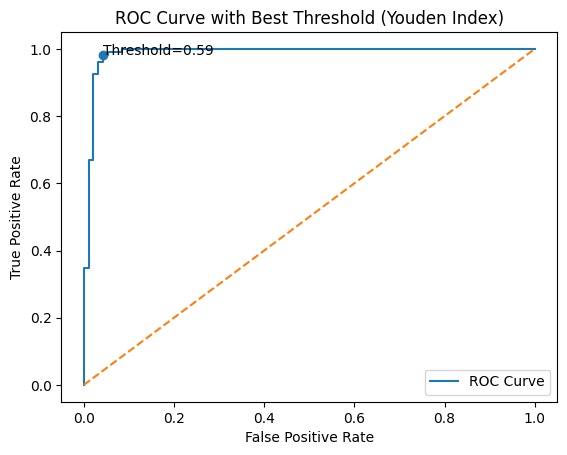

In [92]:
import matplotlib.pyplot as plt

plt.figure()

# ROC curve
plt.plot(fpr, tpr, label="ROC Curve")

# Diagonal line
plt.plot([0, 1], [0, 1], linestyle='--')

# Best point
plt.scatter(best_fpr, best_tpr)
plt.text(best_fpr, best_tpr, f"Threshold={best_threshold:.2f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Best Threshold (Youden Index)")
plt.legend()

plt.show()


# Final

In [93]:
# 1) 
from collections import Counter
y_final = (y_prob > best_threshold).astype(int)

print(y_final)
print(Counter(y_final))

[0 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1
 1 0 1 1 0 1 0 0 1 0 1 1 0 1 1 0 0 0 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 0
 0 0 1 0 0 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1 1 0 0 0 0 1 1 0 1 0 1 1 1
 0 0 1 1 1 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0 0
 0 0 0 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 0 1 0 1 0 0 1 0 0 0
 1 1 1 1 0 0 0 0 0 0 1 1 1 0 1]
Counter({1: 107, 0: 93})


Confusion Matrix:

[[ 90   4]
 [  3 103]]


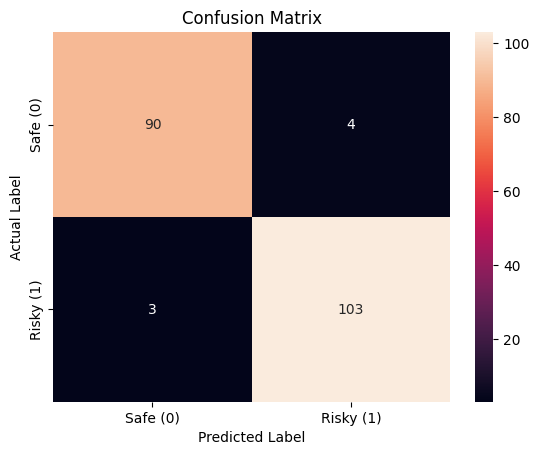

In [94]:
# 2) 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_final)

print("Confusion Matrix:\n")
print(cm)


# Plot heatmap
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0.5, 1.5], ["Safe (0)", "Risky (1)"])
plt.yticks([0.5, 1.5], ["Safe (0)", "Risky (1)"])

plt.show()

In [95]:
# 3) 
tn, fp, fn, tp = cm.ravel()

print("\nDetailed Breakdown:")
print("True Negatives (Correct Safe):", tn)
print("False Positives (Wrongly Rejected Good):", fp)
print("False Negatives (Missed Risky Customer):", fn)
print("True Positives (Correct Risky):", tp)


Detailed Breakdown:
True Negatives (Correct Safe): 90
False Positives (Wrongly Rejected Good): 4
False Negatives (Missed Risky Customer): 3
True Positives (Correct Risky): 103


### Map to Business:
```
TN (Correct Safe) → Good customers approved ✅
TP (Correct Risky) → Bad customers rejected ✅
FP (False Alarm) → Lost good customer ❌
FN (Danger!) → Gave loan to defaulter 🚨

# Now show how to find best model using hyperparameter tuning:
- Activate the above optional cell